In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

(1, 237, 150, 4)
WCS Keywords

Number of WCS axes: 4
CTYPE : 'STOKES' 'AWAV' 'HPLT-TAN' 'HPLN-TAN' 
CRVAL : 1.0 6.301490000000001e-07 0.025464383333333333 -0.009136980555555556 
CRPIX : 1.0 32.5625 116.77143 1303.4156 
PC1_1 PC1_2 PC1_3 PC1_4  : 1.0 0.0 0.0 0.0 
PC2_1 PC2_2 PC2_3 PC2_4  : 0.0 1.0 0.0 0.0 
PC3_1 PC3_2 PC3_3 PC3_4  : 0.0 0.0 0.98972523 0.011515025 
PC4_1 PC4_2 PC4_3 PC4_4  : 0.0 0.0 -0.002325741 0.9896134 
CDELT : 1.0 1.2800000000000002e-12 7.116537222222222e-05 1.4835249444444444e-05 
NAXIS : 4  150  237  1
<CoordinatesMap with 4 world coordinates:

  index                   aliases                    ... format_unit visible
  ----- -------------------------------------------- ... ----------- -------
      0         phys.polarization.stokes stokes stok ...                  no
      1                                   em.wl awav ...           m     yes
      2 custom:pos.helioprojective.lat hplt-tan hplt ...      arcsec     yes
      3 custom:pos.helioprojective.lon hpln

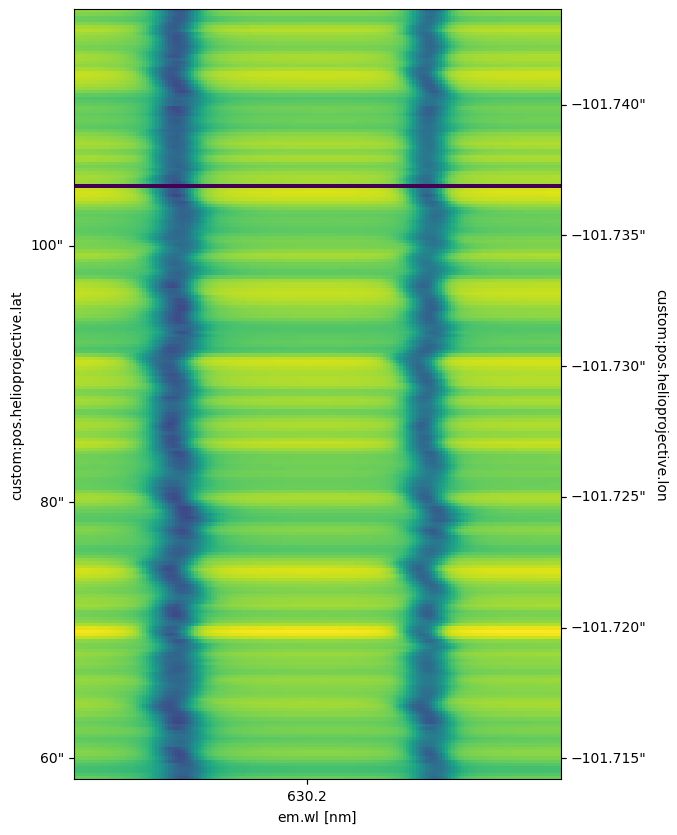

In [2]:
hdul = fits.open('~/Downloads/L2 Sample.fits')
hdu = hdul[14]
wcs = WCS(hdu.header)

print(hdu.data.shape)
print(wcs)

# STOKES AWAV LAT LON
slices = (0, 'x', 'y', 0)
image = hdu.data[0,:,:,0]##.transpose()

plt.figure(figsize=(10, 10))
ax = plt.subplot(projection=wcs, slices=slices)

print(ax.coords)

stokes, wav, hplt, hpln = ax.coords

wav.set_format_unit(u.nm)
wav.set_major_formatter('x.x')

ax.imshow(image)

In [3]:
hdul.info()

Filename: /home/han/Downloads/L2 Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      74   ()      
  1  Log of Optical Depth at 500nm    1 ImageHDU        79   (81, 237, 1)   float32   
  2  Temperature    1 ImageHDU        79   (81, 237, 1)   float32   
  3  Electron Pressure    1 ImageHDU        79   (81, 237, 1)   float32   
  4  Microturbulence    1 ImageHDU        79   (81, 237, 1)   float32   
  5  Magnetic Field Strength    1 ImageHDU        79   (81, 237, 1)   float32   
  6  Line-of-sight Velocity    1 ImageHDU        79   (81, 237, 1)   float32   
  7  Magnetic Field Inclination (w.r.t. line-of-sight)    1 ImageHDU        79   (81, 237, 1)   float32   
  8  Magnetic Field Azimuth (w.r.t. line-of-sight)    1 ImageHDU        79   (81, 237, 1)   float32   
  9  Geometric Height above solar surface (tau ~ 1 at 500nm)    1 ImageHDU        79   (81, 237, 1)   float32   
 10  Gas Pressure    1 ImageHDU        79   (81, 237, 

In [4]:
hdul[2].data

array([[[ 8831.16,  8555.25,  8275.53, ..., 25974.  , 31202.64,
         43501.54],
        [ 7065.36,  7055.31,  7014.44, ...,  8137.71, 10406.48,
         19511.79],
        [ 6477.45,  6537.05,  6560.21, ...,  8530.26, 10886.17,
         20098.93],
        ...,
        [ 6796.17,  6826.09,  6823.7 , ...,  6783.6 ,  8983.08,
         18018.14],
        [ 6588.14,  6668.36,  6711.  , ..., 14628.79, 18178.95,
         28712.2 ],
        [ 6157.5 ,  6329.86,  6453.2 , ...,  7763.74, 10155.16,
         19389.59]]], dtype='>f4')

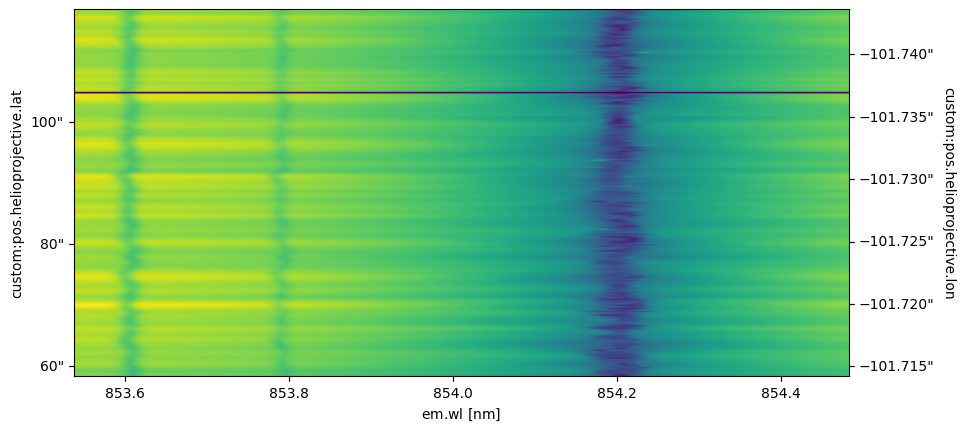

In [6]:
image2 = hdul[15].data[0,:,:,0]
wcs = WCS(hdul[15].header)
plt.figure(figsize=(10, 10))
ax = plt.subplot(projection=wcs, slices=slices)

stokes, wav, hplt, hpln = ax.coords
wav.set_format_unit(u.nm)
wav.set_major_formatter('x.x')

ax.imshow(image2)
plt.show()


print(wav)